In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

diabetes=load_diabetes()


In [2]:
df= pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)

In [3]:
df.shape

(442, 10)

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [5]:
#checking the null values in the dataset
df.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


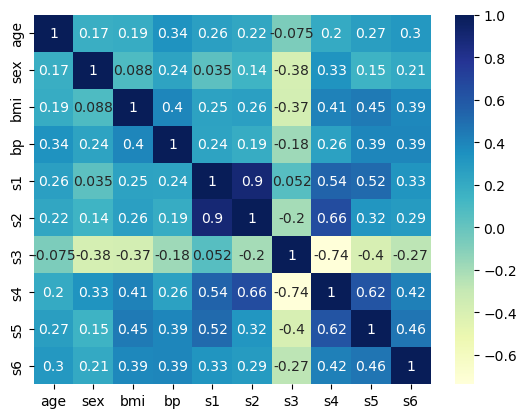

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(), cmap="YlGnBu",  annot= True)
plt.show()

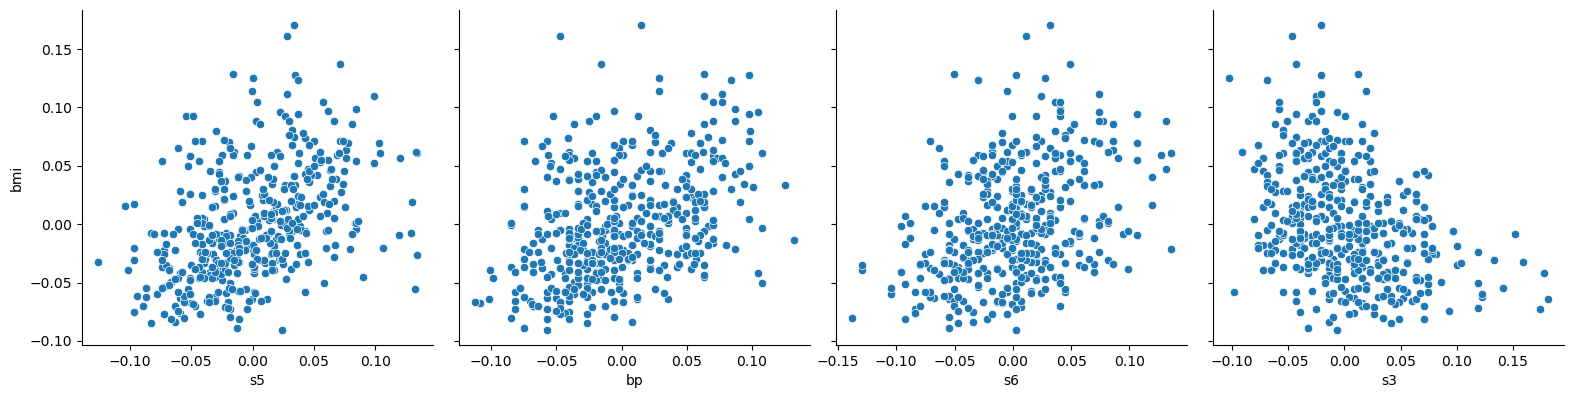

In [8]:
sns.pairplot(df, x_vars=['s5', 'bp','s6','s3'], y_vars ='bmi', height=4, aspect=1, kind='scatter')
plt.show()

In [9]:
#X= df.drop(['bmi'], axis=1)
y=df['bmi']
X = df[['s5', 'bp', 's6', 's3']]

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test= train_test_split(X, y, test_size=0.30,random_state=42)

In [11]:
X_train.shape, X_test.shape

((309, 4), (133, 4))

In [12]:
from sklearn import linear_model
model=linear_model.LinearRegression()
lr=model.fit(X_train, y_train)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error,r2_score
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared: ", r2_score(y_test,y_pred))

RMSE:  0.039432904833381334
R-squared:  0.2617421588036496


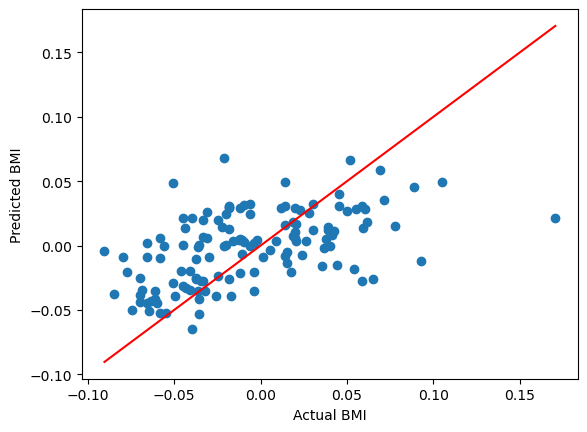

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [16]:
 #importing statmodels library to perform linear regression
import statsmodels.api as sm

 # Add a constant to get an intercept
X_train_sm =sm.add_constant(X_train)
# Fit the resgression line using 'OLS'
lr=sm.OLS(y_train, X_train_sm).fit()

In [17]:
# Print the parameters,i.e. intercept and slope of the regression line obtained
lr.params

const    0.001632
s5       0.214681
bp       0.228530
s6       0.142434
s3      -0.222610
dtype: float64

In [18]:
 #Performing a summary operation lists out all different parameters of the regression
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     36.08
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.13e-24
Time:                        17:34:31   Log-Likelihood:                 560.01
No. Observations:                 309   AIC:                            -1110.
Df Residuals:                     304   BIC:                            -1091.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.002      0.719      0.4

In [19]:
# Add a constant to x_test
X_test_sm =sm.add_constant(X_test)
# Predict the y values corresponding to x_test_sm
y_pred =lr.predict(X_test_sm)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
#RMSE value
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
#R-squared value
print("R-squared: ", r2_score(y_test,y_pred))

RMSE:  0.03943290483338133
R-squared:  0.2617421588036497


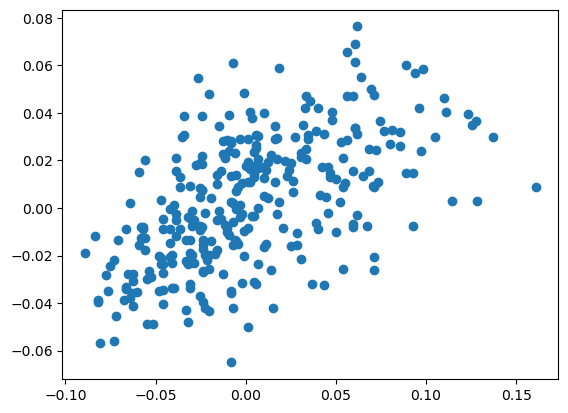

In [21]:
y_pred_manual = (
    0.0016
    + 0.2147 * X_train['s5']
    + 0.2285 * X_train['bp']
    + 0.1424 * X_train['s6']
    - 0.2226 * X_train['s3']
)
plt.scatter(y_train, y_pred_manual)
plt.show()



In [22]:
def predict_bmi(s5, bp, s6, s3):
    return 0.0016 + 0.2147*s5 + 0.2285*bp + 0.1424*s6 - 0.2226*s3

# predict BMI for following values
#s5= 0.002961  , bp = 0.021872, s6= -0.046641, s3= 0.074412
predicted_bmi = predict_bmi(0.002961, 0.071872, 0.046641, 0.024412)
print("The predicted BMI is :",predicted_bmi)


The predicted BMI is : 0.019866045900000004
